# IFRS 9 Expected Credit Loss (ECL) Model
## Logistic Regression for Probability of Default (PD)
### ECL = EAD × PD × LGD

---
**Framework:** IFRS 9 Financial Instruments  
**Model:** Logistic Regression (scikit-learn)  
**Dataset:** 12,000 synthetic loan transactions  
**Sections:**
1. Setup & Data Generation  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering & Preprocessing  
4. Logistic Regression – PD Model  
5. Model Evaluation  
6. ECL Computation (EAD × PD × LGD)  
7. IFRS 9 Staging & Portfolio Summary  
8. Visualisations & Dashboard


## 1. Setup & Library Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)


In [6]:
# Plot style

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.color': '#DEE2E6',
    'grid.linewidth': 0.7,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#1F3864', '#2E75B6', '#70AD47', '#ED7D31', '#FF0000', '#FFC000']

print("✅ Libraries loaded successfully")
print(f"   pandas  {pd.__version__} | numpy {np.__version__}")    

✅ Libraries loaded successfully
   pandas  2.3.3 | numpy 2.3.5


## 2. Synthetic Data Generation

We simulate **12,000 loan transactions** with realistic credit risk features.  
The true default probability follows a logistic model so our fitted model has  
a known ground truth to recover.


In [7]:
np.random.seed(42)
N = 12_000

# ── Borrower & loan features ──────────────────────────────────────────────
credit_score      = np.random.normal(650, 80, N).clip(300, 850)
debt_to_income    = np.random.beta(2, 5, N) * 100          # %
loan_to_value     = np.random.beta(3, 4, N) * 100          # %
months_on_books   = np.random.randint(1, 120, N)
num_delinquencies = np.random.poisson(0.5, N).clip(0, 10)
employment_years  = np.random.exponential(5, N).clip(0, 40)
loan_amount       = np.random.lognormal(10, 0.8, N).clip(1_000, 500_000)
interest_rate     = np.random.normal(7.5, 2.5, N).clip(2, 25)   # %
loan_term_months  = np.random.choice([12, 24, 36, 48, 60, 84, 120], N)
collateral_value  = loan_amount * np.random.uniform(0.5, 2.0, N)

# ── True latent PD (logistic) ─────────────────────────────────────────────
log_odds = (
    -2.0
    - 0.006 * credit_score
    + 0.025 * debt_to_income
    + 0.020 * loan_to_value
    - 0.005 * months_on_books
    + 0.500 * num_delinquencies
    - 0.040 * employment_years
    + 0.080 * interest_rate
    + np.random.normal(0, 0.5, N)          # idiosyncratic noise
)
true_pd      = 1 / (1 + np.exp(-log_odds))
default_flag = (np.random.uniform(0, 1, N) < true_pd).astype(int)

# ── IFRS 9 Stage assignment ────────────────────────────────────────────────
stage = np.where(default_flag == 1, 3,
        np.where((num_delinquencies >= 2) | (true_pd > 0.15), 2, 1))

# ── EAD and LGD ───────────────────────────────────────────────────────────
ead = loan_amount * np.random.uniform(0.85, 1.0, N)
lgd = np.where(
    collateral_value > loan_amount,
    np.random.uniform(0.10, 0.30, N),
    np.random.uniform(0.40, 0.70, N)
).clip(0.05, 0.95)

tranx_df = pd.DataFrame({
    'CustomerID'      : [f'CUST{i:06d}' for i in range(1, N+1)],
    'CreditScore'     : credit_score.round(0),
    'DebtToIncome'    : debt_to_income.round(2),
    'LoanToValue'     : loan_to_value.round(2),
    'MonthsOnBooks'   : months_on_books,
    'NumDelinquencies': num_delinquencies,
    'EmploymentYears' : employment_years.round(1),
    'LoanAmount'      : loan_amount.round(2),
    'InterestRate'    : interest_rate.round(2),
    'LoanTermMonths'  : loan_term_months,
    'CollateralValue' : collateral_value.round(2),
    'DefaultFlag'     : default_flag,
    'Stage'           : stage,
    'EAD'             : ead.round(2),
    'LGD'             : lgd.round(4),
})

print(f"Dataset shape : {tranx_df.shape}")
print(f"Default rate  : {default_flag.mean():.2%}  ({default_flag.sum():,} defaults)")
print(f"Stage 1 (Performing) : {(stage==1).sum():,}  ({(stage==1).mean():.1%})")
print(f"Stage 2 (SICR)       : {(stage==2).sum():,}  ({(stage==2).mean():.1%})")
print(f"Stage 3 (Default)    : {(stage==3).sum():,}  ({(stage==3).mean():.1%})")
tranx_df.head()


Dataset shape : (12000, 15)
Default rate  : 3.04%  (365 defaults)
Stage 1 (Performing) : 10,563  (88.0%)
Stage 2 (SICR)       : 1,072  (8.9%)
Stage 3 (Default)    : 365  (3.0%)


,CustomerID,CreditScore,DebtToIncome,LoanToValue,MonthsOnBooks,NumDelinquencies,EmploymentYears,LoanAmount,InterestRate,LoanTermMonths,CollateralValue,DefaultFlag,Stage,EAD,LGD
0,CUST000001,690.0,68.83,25.54,66,3,1.5,17915.75,8.16,120,34770.90,0,2,16854.88,0.1112
1,CUST000002,639.0,24.98,48.58,71,0,1.9,13557.53,8.63,120,23497.74,0,1,12862.46,0.1427
2,CUST000003,702.0,24.34,44.65,75,0,0.0,21065.64,13.05,36,40120.10,0,1,19664.14,0.1923
3,CUST000004,772.0,12.50,15.94,65,1,6.8,16684.09,7.16,84,24062.98,0,1,16448.34,0.1185
4,CUST000005,631.0,44.32,44.98,78,0,5.5,17061.17,9.43,24,12372.97,0,1,15341.53,0.6668


## 3. Exploratory Data Analysis (EDA)

In [8]:
print("=== Dataset Info ===")
print(tranx_df.dtypes)
print("\n=== Missing Values ===")
print(tranx_df.isnull().sum())
print("\n=== Descriptive Statistics ===")
tranx_df.describe().round(2)


=== Dataset Info ===
CustomerID           object
CreditScore         float64
DebtToIncome        float64
LoanToValue         float64
MonthsOnBooks         int32
NumDelinquencies      int32
EmploymentYears     float64
LoanAmount          float64
InterestRate        float64
LoanTermMonths        int64
CollateralValue     float64
DefaultFlag           int64
Stage                 int64
EAD                 float64
LGD                 float64
dtype: object

=== Missing Values ===
CustomerID          0
CreditScore         0
DebtToIncome        0
LoanToValue         0
MonthsOnBooks       0
NumDelinquencies    0
EmploymentYears     0
LoanAmount          0
InterestRate        0
LoanTermMonths      0
CollateralValue     0
DefaultFlag         0
Stage               0
EAD                 0
LGD                 0
dtype: int64

=== Descriptive Statistics ===


,CreditScore,DebtToIncome,LoanToValue,MonthsOnBooks,NumDelinquencies,EmploymentYears,LoanAmount,InterestRate,LoanTermMonths,CollateralValue,DefaultFlag,Stage,EAD,LGD
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,649.36,28.38,42.51,59.65,0.49,5.05,30824.07,7.49,54.78,38257.30,0.03,1.15,28506.70,0.32
std,79.66,15.75,17.45,34.40,0.70,4.97,29563.40,2.48,34.51,41450.98,0.17,0.43,27355.72,0.18
min,336.00,0.07,0.80,1.00,0.00,0.00,1088.84,2.00,12.00,635.33,0.00,1.00,1035.58,0.10
25%,596.00,16.10,29.41,29.00,0.00,1.50,13072.60,5.79,24.00,14321.13,0.00,1.00,12105.90,0.18
50%,649.00,26.43,41.92,60.00,0.00,3.50,22590.16,7.46,48.00,26298.06,0.00,1.00,20799.38,0.25
75%,703.00,38.62,54.84,89.00,1.00,7.00,38392.77,9.15,84.00,46901.20,0.00,1.00,35495.25,0.48
max,850.00,85.99,96.13,119.00,6.00,40.00,500000.00,17.21,120.00,686613.37,1.00,3.00,460841.05,0.70


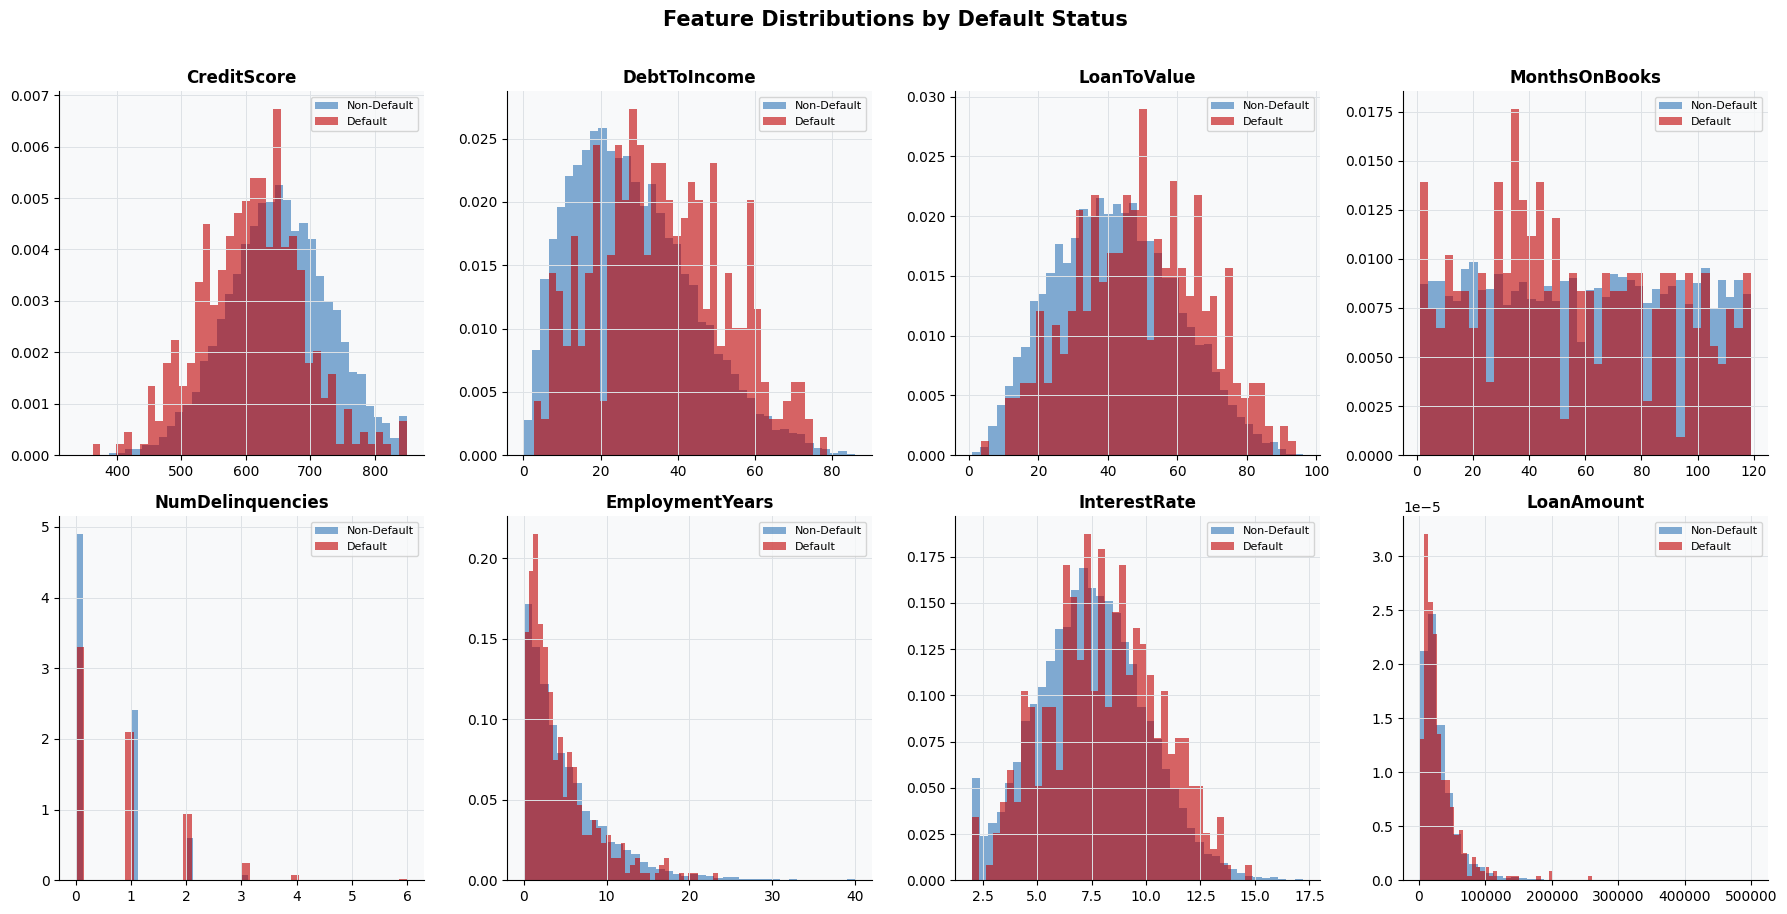

✅ EDA plot saved


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Feature Distributions by Default Status', fontsize=15, fontweight='bold', y=1.01)

features_plot = ['CreditScore','DebtToIncome','LoanToValue','MonthsOnBooks',
                 'NumDelinquencies','EmploymentYears','InterestRate','LoanAmount']
labels = {0: 'Non-Default', 1: 'Default'}
colors = {0: '#2E75B6', 1: '#C00000'}

for ax, feat in zip(axes.flat, features_plot):
    for flag, grp in tranx_df.groupby('DefaultFlag'):
        ax.hist(grp[feat], bins=40, alpha=0.6, color=colors[flag],
                label=labels[flag], density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved")


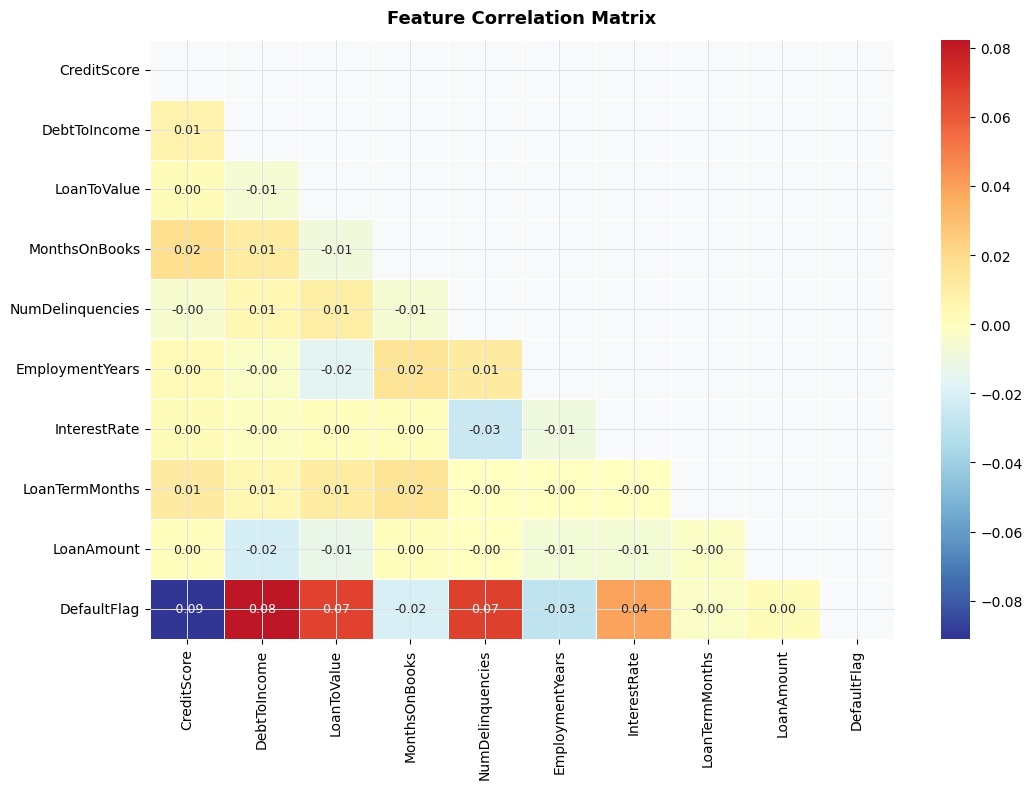

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 8))
num_cols = ['CreditScore','DebtToIncome','LoanToValue','MonthsOnBooks',
            'NumDelinquencies','EmploymentYears','InterestRate','LoanTermMonths',
            'LoanAmount','DefaultFlag']
corr = tranx_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()


## 4. Feature Engineering & Train/Test Split

In [11]:
# features
FEATURES = [
    'CreditScore', 'DebtToIncome', 'LoanToValue', 'MonthsOnBooks',
    'NumDelinquencies', 'EmploymentYears', 'InterestRate', 'LoanTermMonths'
]
TARGET = 'DefaultFlag'

X = tranx_df[FEATURES].values
y = tranx_df[TARGET].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(N),
    test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X)

print(f"Training set : {X_train.shape[0]:,} rows  |  Default rate: {y_train.mean():.2%}")
print(f"Test set     : {X_test.shape[0]:,} rows  |  Default rate: {y_test.mean():.2%}")
print(f"Features     : {FEATURES}")


Training set : 9,600 rows  |  Default rate: 3.04%
Test set     : 2,400 rows  |  Default rate: 3.04%
Features     : ['CreditScore', 'DebtToIncome', 'LoanToValue', 'MonthsOnBooks', 'NumDelinquencies', 'EmploymentYears', 'InterestRate', 'LoanTermMonths']


## 5. Logistic Regression – PD Model

The logistic regression estimates:

$$\text{PD}_i = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$

We use `class_weight='balanced'` to handle class imbalance.


In [12]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)
lr_model.fit(X_train_s, y_train)

# Predict on full dataset
tranx_df['PD'] = lr_model.predict_proba(X_all_s)[:, 1]

print(f"Model intercept : {lr_model.intercept_[0]:.6f}")
print()
coef_tranx_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio' : np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)
print(coef_tranx_df.to_string(index=False))


Model intercept : -0.391248

         Feature  Coefficient  Odds Ratio
    DebtToIncome     0.503449    1.654417
     LoanToValue     0.290299    1.336827
NumDelinquencies     0.234308    1.264034
    InterestRate     0.197653    1.218539
  LoanTermMonths    -0.019940    0.980257
   MonthsOnBooks    -0.202414    0.816757
 EmploymentYears    -0.203001    0.816277
     CreditScore    -0.574311    0.563093


In [13]:
# Cross-validation AUC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(lr_model, X_all_s, y, cv=cv, scoring='roc_auc')
print(f"5-Fold CV AUC : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print(f"Fold AUCs     : {[round(a,4) for a in cv_aucs]}")


5-Fold CV AUC : 0.7393 ± 0.0272
Fold AUCs     : [np.float64(0.7379), np.float64(0.7407), np.float64(0.7757), np.float64(0.692), np.float64(0.7504)]


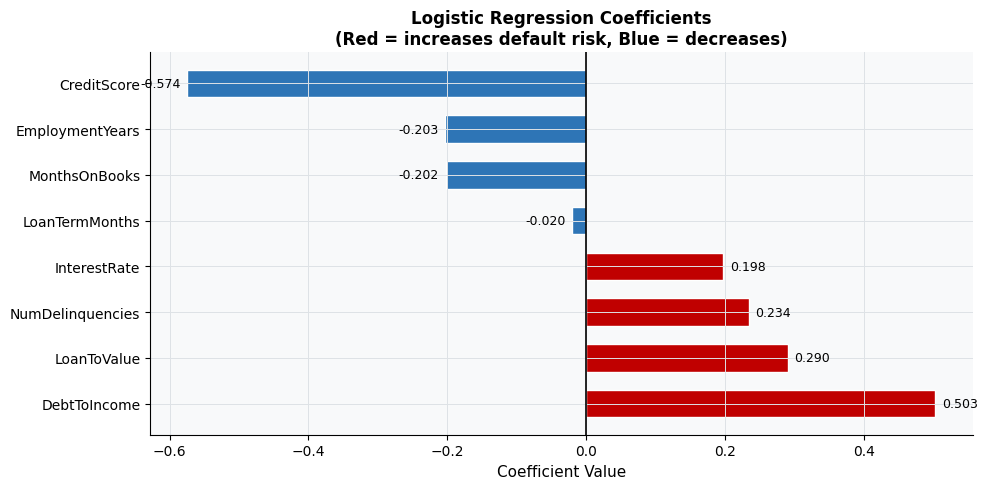

In [14]:
# Coefficient bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#C00000' if c > 0 else '#2E75B6' for c in coef_tranx_df['Coefficient']]
bars = ax.barh(coef_tranx_df['Feature'], coef_tranx_df['Coefficient'], color=colors_bar,
               edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.set_title('Logistic Regression Coefficients\n(Red = increases default risk, Blue = decreases)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, coef_tranx_df['Coefficient']):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('coefficients.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Model Evaluation

In [15]:
y_prob_test = lr_model.predict_proba(X_test_s)[:, 1]
y_pred_test = lr_model.predict(X_test_s)

auc_score = roc_auc_score(y_test, y_prob_test)
print(f"AUC-ROC   : {auc_score:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['Non-Default','Default']))


AUC-ROC   : 0.7490

              precision    recall  f1-score   support

 Non-Default       0.98      0.68      0.80      2327
     Default       0.06      0.66      0.11        73

    accuracy                           0.68      2400
   macro avg       0.52      0.67      0.46      2400
weighted avg       0.96      0.67      0.78      2400



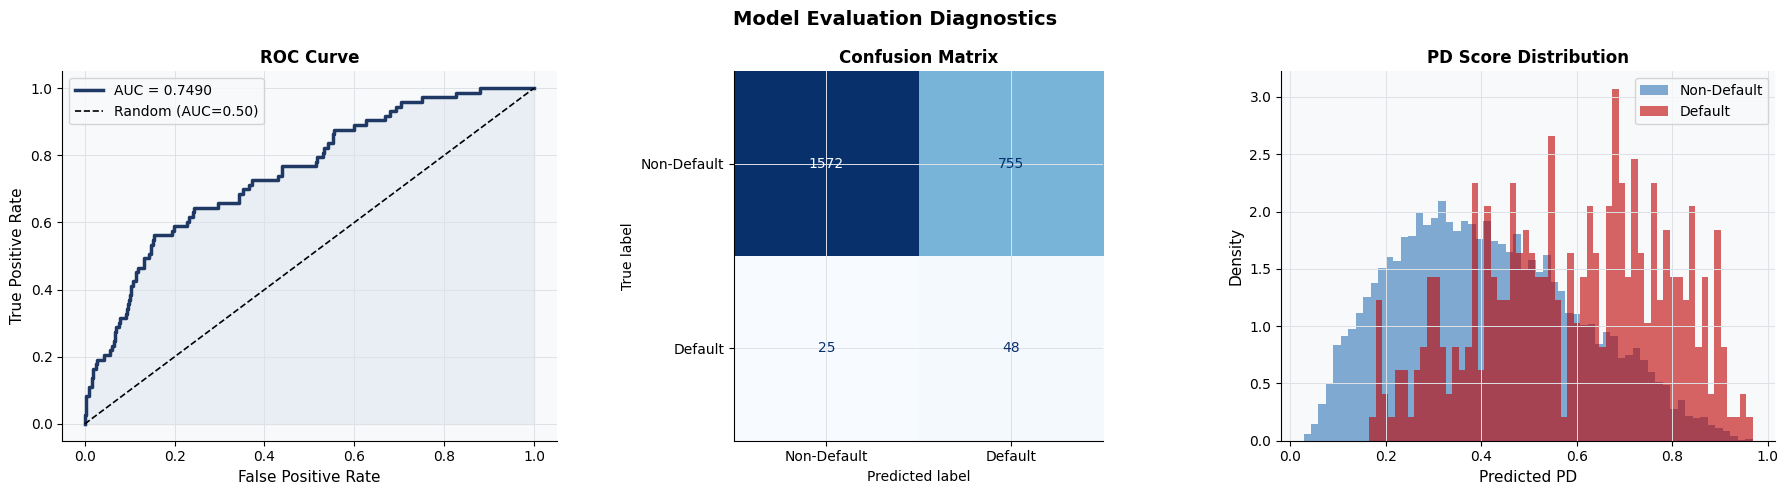

In [16]:
# dashboard showing model evaluation diagnostics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation Diagnostics', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0].plot(fpr, tpr, color='#1F3864', lw=2.5, label=f'AUC = {auc_score:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1.2, label='Random (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2E75B6')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Default','Default'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# PD Distribution histogram
axes[2].hist(tranx_df.loc[tranx_df['DefaultFlag']==0, 'PD'], bins=60, alpha=0.6,
             color='#2E75B6', label='Non-Default', density=True)
axes[2].hist(tranx_df.loc[tranx_df['DefaultFlag']==1, 'PD'], bins=60, alpha=0.6,
             color='#C00000', label='Default', density=True)
axes[2].set_xlabel('Predicted PD', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].set_title('PD Score Distribution', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()


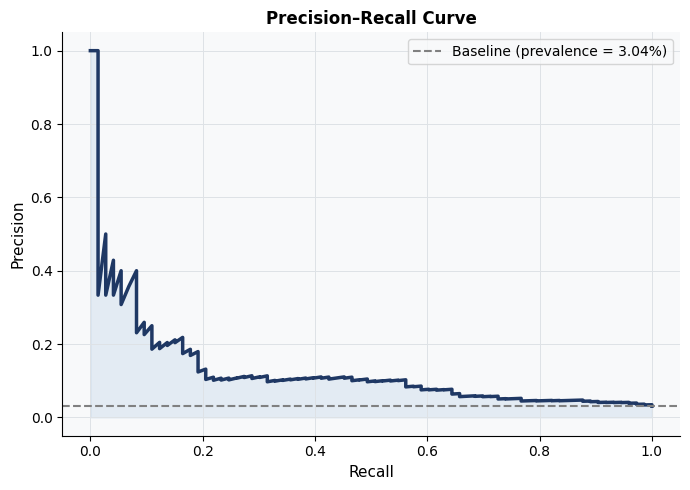

In [17]:
# Precision-Recall curve

prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color='#1F3864', lw=2.5)
ax.fill_between(rec, prec, alpha=0.1, color='#2E75B6')
baseline = y_test.mean()
ax.axhline(baseline, color='grey', lw=1.5, linestyle='--',
           label=f'Baseline (prevalence = {baseline:.2%})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision–Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 7. ECL Computation

$$\text{ECL}_i = \text{EAD}_i \times \text{PD}_i \times \text{LGD}_i$$


In [18]:
tranx_df['ECL'] = tranx_df['EAD'] * tranx_df['PD'] * tranx_df['LGD']

print("=== Portfolio ECL Summary ===")
print(f"Total EAD   : Kes{tranx_df['EAD'].sum():>15,.0f}")
print(f"Total ECL   : Kes{tranx_df['ECL'].sum():>15,.0f}")
print(f"ECL / EAD   : {tranx_df['ECL'].sum()/tranx_df['EAD'].sum():.2%}  (Coverage Ratio)")
print(f"Avg PD      : {tranx_df['PD'].mean():.4%}")
print(f"Avg LGD     : {tranx_df['LGD'].mean():.4%}")


=== Portfolio ECL Summary ===
Total EAD   : Kes    342,080,424
Total ECL   : Kes     45,356,005
ECL / EAD   : 13.26%  (Coverage Ratio)
Avg PD      : 41.7756%
Avg LGD     : 32.0864%


In [19]:
# PD bucket analysis

pd_bins   = [0, 0.02, 0.05, 0.10, 0.20, 0.50, 1.01]
pd_labels = ['0–2%','2–5%','5–10%','10–20%','20–50%','50–100%']
tranx_df['PD_Bucket'] = pd.cut(tranx_df['PD'], bins=pd_bins, labels=pd_labels, right=False)

pd_summary = tranx_df.groupby('PD_Bucket', observed=True).agg(
    Transactions  = ('PD', 'count'),
    Avg_PD        = ('PD', 'mean'),
    Total_EAD     = ('EAD', 'sum'),
    Total_ECL     = ('ECL', 'sum'),
    Default_Rate  = ('DefaultFlag', 'mean')
).reset_index()
pd_summary['Coverage'] = pd_summary['Total_ECL'] / pd_summary['Total_EAD']
pd_summary['Pct_Portfolio'] = pd_summary['Transactions'] / N

fmt = {
    'Avg_PD'       : '{:.2%}'.format,
    'Total_EAD'    : 'Kes{:,.0f}'.format,
    'Total_ECL'    : 'Kes{:,.0f}'.format,
    'Default_Rate' : '{:.2%}'.format,
    'Coverage'     : '{:.2%}'.format,
    'Pct_Portfolio': '{:.1%}'.format,
}
display(pd_summary.style.format(fmt).set_caption('PD Bucket Summary'))


,PD_Bucket,Transactions,Avg_PD,Total_EAD,Total_ECL,Default_Rate,Coverage,Pct_Portfolio
0,2–5%,15,4.10%,"Kes432,178","Kes4,838",0.00%,1.12%,0.1%
1,5–10%,254,8.12%,"Kes7,501,769","Kes205,389",0.00%,2.74%,2.1%
2,10–20%,1374,15.57%,"Kes40,805,268","Kes2,059,112",0.66%,5.05%,11.5%
3,20–50%,6398,34.95%,"Kes182,358,393","Kes20,453,622",1.81%,11.22%,53.3%
4,50–100%,3959,64.20%,"Kes110,982,816","Kes22,633,045",6.06%,20.39%,33.0%


## 8. IFRS 9 Staging & Portfolio Summary

| Stage | Criterion | ECL Horizon |
|-------|-----------|-------------|
| 1 | Performing – no SICR | 12-month ECL |
| 2 | Significant Increase in Credit Risk (SICR) | Lifetime ECL |
| 3 | Credit-impaired (defaulted) | Lifetime ECL |


In [20]:
# summarizing the data 

stage_summary = tranx_df.groupby('Stage').agg(
    Transactions   = ('CustomerID', 'count'),
    Total_EAD      = ('EAD', 'sum'),
    Total_ECL      = ('ECL', 'sum'),
    Avg_PD         = ('PD', 'mean'),
    Avg_LGD        = ('LGD', 'mean'),
).reset_index()
stage_summary['Coverage_Ratio'] = stage_summary['Total_ECL'] / stage_summary['Total_EAD']
stage_summary['Pct_Portfolio']  = stage_summary['Transactions'] / N

stage_labels = {1:'Stage 1 – Performing', 2:'Stage 2 – SICR', 3:'Stage 3 – Default'}
stage_summary['Description'] = stage_summary['Stage'].map(stage_labels)

fmt2 = {
    'Total_EAD'     : 'Kes{:,.0f}'.format,
    'Total_ECL'     : 'Kes{:,.0f}'.format,
    'Avg_PD'        : '{:.2%}'.format,
    'Avg_LGD'       : '{:.2%}'.format,
    'Coverage_Ratio': '{:.2%}'.format,
    'Pct_Portfolio' : '{:.1%}'.format,
}
display(stage_summary[['Stage','Description','Transactions','Pct_Portfolio',
                        'Total_EAD','Avg_PD','Avg_LGD','Total_ECL','Coverage_Ratio'
                       ]].style.format(fmt2).set_caption('IFRS 9 ECL by Stage'))


,Stage,Description,Transactions,Pct_Portfolio,Total_EAD,Avg_PD,Avg_LGD,Total_ECL,Coverage_Ratio
0,1,Stage 1 – Performing,10563,88.0%,"Kes301,590,064",39.89%,32.03%,"Kes38,279,117",12.69%
1,2,Stage 2 – SICR,1072,8.9%,"Kes30,003,618",54.46%,32.43%,"Kes5,101,123",17.00%
2,3,Stage 3 – Default,365,3.0%,"Kes10,486,742",59.07%,32.63%,"Kes1,975,765",18.84%


In [21]:
# Grand totals

print("\n=== TOTAL PORTFOLIO ===")
print(f"  Transactions : {N:,}")
print(f"  Total EAD    : Kes{tranx_df['EAD'].sum():,.0f}")
print(f"  Total ECL    : Kes{tranx_df['ECL'].sum():,.0f}")
print(f"  ECL Rate     : {tranx_df['ECL'].sum()/tranx_df['EAD'].sum():.2%}")
print()
for _, r in stage_summary.iterrows():
    print(f"  {stage_labels[int(r['Stage'])]:30s}  "
          f"ECL = Kes{r['Total_ECL']:>12,.0f}  "
          f"({r['Total_ECL']/tranx_df['ECL'].sum():.1%} of total)")



=== TOTAL PORTFOLIO ===
  Transactions : 12,000
  Total EAD    : Kes342,080,424
  Total ECL    : Kes45,356,005
  ECL Rate     : 13.26%

  Stage 1 – Performing            ECL = Kes  38,279,117  (84.4% of total)
  Stage 2 – SICR                  ECL = Kes   5,101,123  (11.2% of total)
  Stage 3 – Default               ECL = Kes   1,975,765  (4.4% of total)


## 9. Visualisations & ECL Dashboard

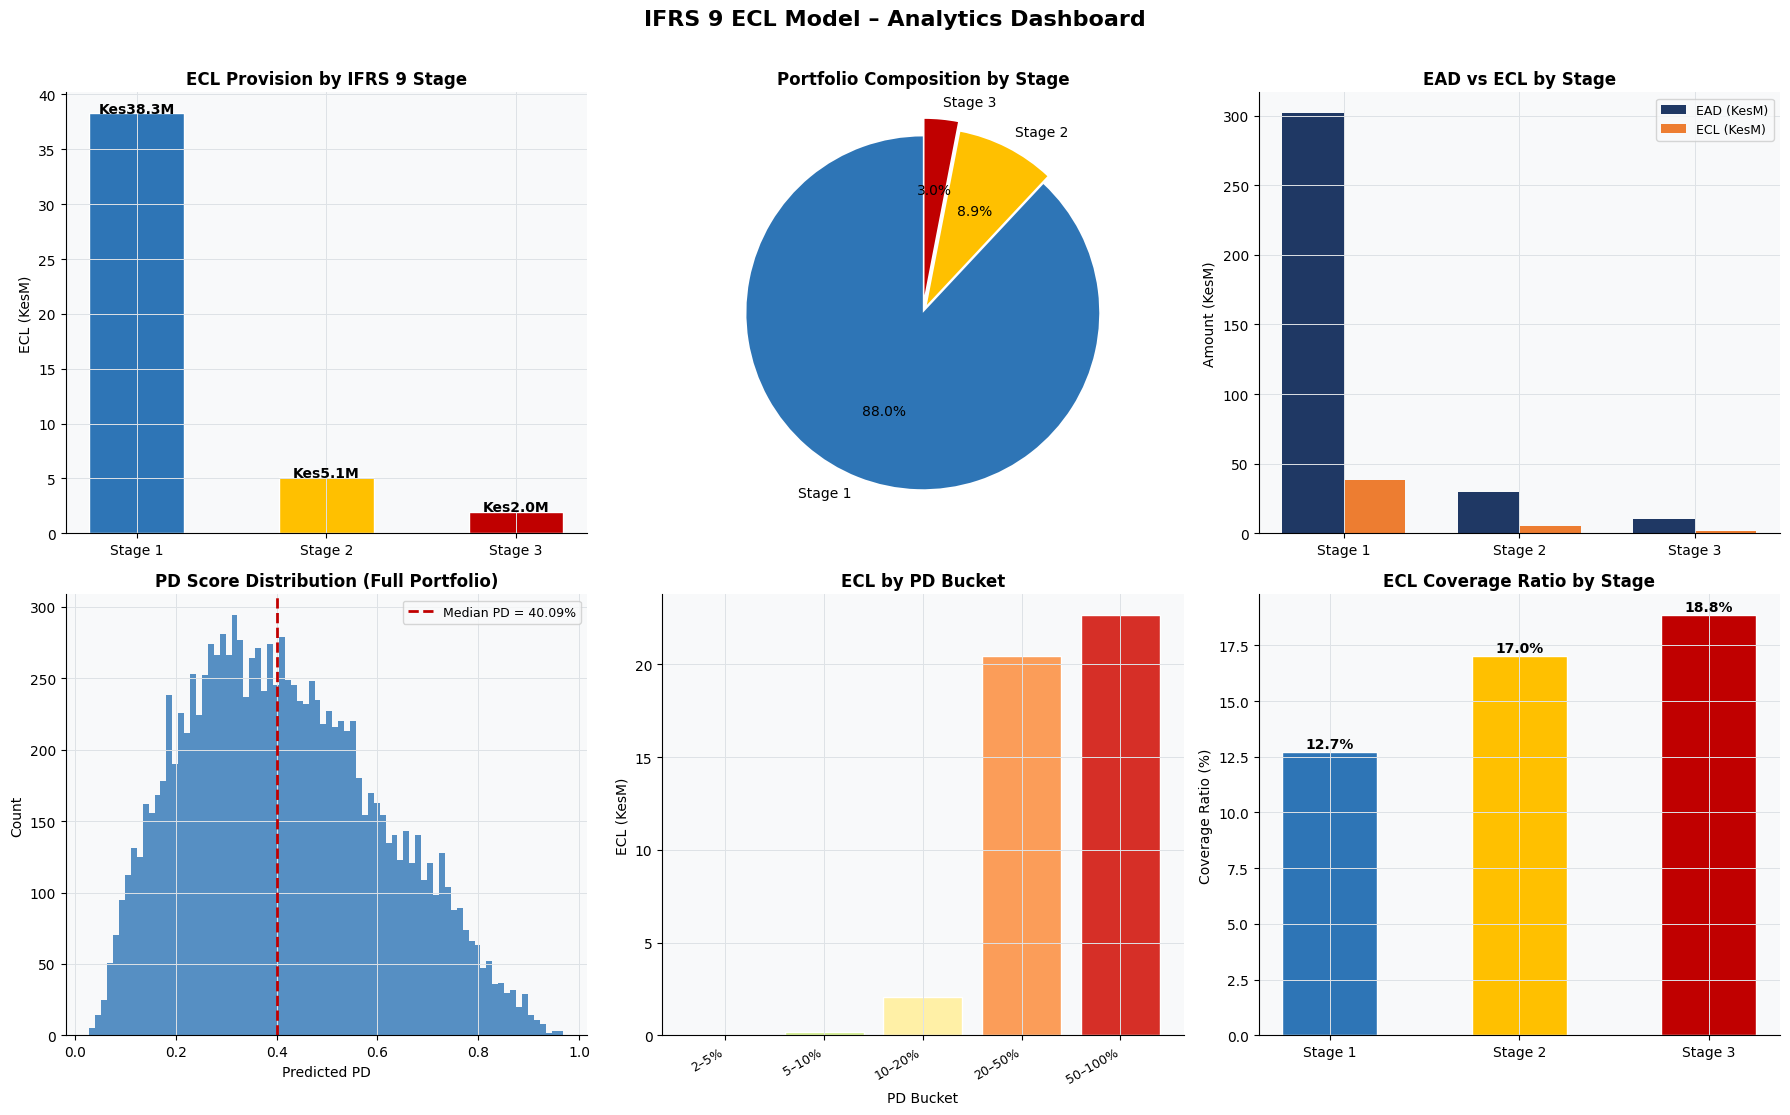

✅ ECL dashboard saved


In [22]:
# ── Dashboard: 2×3 grid ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('IFRS 9 ECL Model – Analytics Dashboard', fontsize=16,
             fontweight='bold', y=1.01)

STAGE_COLORS = {1:'#2E75B6', 2:'#FFC000', 3:'#C00000'}

# 1) ECL by Stage (bar)
ax = axes[0, 0]
st_labels = [f'Stage {s}' for s in stage_summary['Stage']]
ecl_vals   = stage_summary['Total_ECL'] / 1e6
bars = ax.bar(st_labels, ecl_vals, color=[STAGE_COLORS[s] for s in stage_summary['Stage']],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, ecl_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'Kes{v:.1f}M', ha='center', fontsize=10, fontweight='bold')
ax.set_title('ECL Provision by IFRS 9 Stage', fontweight='bold')
ax.set_ylabel('ECL (KesM)')

# 2) Portfolio composition (pie)
ax = axes[0, 1]
sizes = stage_summary['Transactions']
explode = [0, 0.05, 0.10]
ax.pie(sizes, labels=st_labels, autopct='%1.1f%%', startangle=90,
       colors=[STAGE_COLORS[s] for s in stage_summary['Stage']],
       explode=explode, textprops={'fontsize':10})
ax.set_title('Portfolio Composition by Stage', fontweight='bold')

# 3) EAD vs ECL by Stage
ax = axes[0, 2]
x = np.arange(len(stage_summary))
w = 0.35
ax.bar(x-w/2, stage_summary['Total_EAD']/1e6, w, label='EAD (KesM)', color='#1F3864')
ax.bar(x+w/2, stage_summary['Total_ECL']/1e6, w, label='ECL (KesM)', color='#ED7D31')
ax.set_xticks(x); ax.set_xticklabels(st_labels)
ax.set_title('EAD vs ECL by Stage', fontweight='bold')
ax.set_ylabel('Amount (KesM)')
ax.legend(fontsize=9)

# 4) PD distribution (histogram)
ax = axes[1, 0]
ax.hist(tranx_df['PD'], bins=80, color='#2E75B6', edgecolor='none', alpha=0.8)
ax.axvline(tranx_df['PD'].median(), color='#C00000', lw=2, linestyle='--',
           label=f"Median PD = {tranx_df['PD'].median():.2%}")
ax.set_xlabel('Predicted PD')
ax.set_ylabel('Count')
ax.set_title('PD Score Distribution (Full Portfolio)', fontweight='bold')
ax.legend(fontsize=9)

# 5) ECL by PD bucket
ax = axes[1, 1]
colors_bucket = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(pd_summary)))
ax.bar(pd_summary['PD_Bucket'].astype(str), pd_summary['Total_ECL']/1e6,
       color=colors_bucket, edgecolor='white')
ax.set_xlabel('PD Bucket')
ax.set_ylabel('ECL (KesM)')
ax.set_title('ECL by PD Bucket', fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# 6) Coverage ratio by stage
ax = axes[1, 2]
coverage = stage_summary['Coverage_Ratio'] * 100
bars = ax.bar(st_labels, coverage,
              color=[STAGE_COLORS[s] for s in stage_summary['Stage']],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, coverage):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('ECL Coverage Ratio by Stage', fontweight='bold')
ax.set_ylabel('Coverage Ratio (%)')

plt.tight_layout()
plt.savefig('ecl_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ ECL dashboard saved")


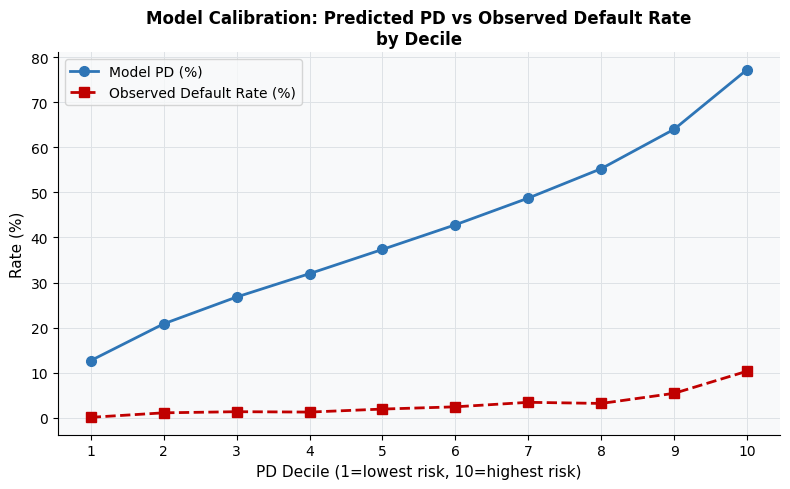

In [23]:
# Calibration: Average PD vs Observed Default Rate by decile
tranx_df_sorted = tranx_df.sort_values('PD').reset_index(drop=True)
tranx_df_sorted['Decile'] = pd.qcut(tranx_df_sorted['PD'], q=10, labels=False) + 1

calib = tranx_df_sorted.groupby('Decile').agg(
    Avg_PD       =('PD', 'mean'),
    Observed_DR  =('DefaultFlag', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(calib['Decile'], calib['Avg_PD']*100,   'o-', color='#2E75B6', lw=2,
        label='Model PD (%)', markersize=7)
ax.plot(calib['Decile'], calib['Observed_DR']*100, 's--', color='#C00000', lw=2,
        label='Observed Default Rate (%)', markersize=7)
ax.set_xlabel('PD Decile (1=lowest risk, 10=highest risk)', fontsize=11)
ax.set_ylabel('Rate (%)', fontsize=11)
ax.set_title('Model Calibration: Predicted PD vs Observed Default Rate\nby Decile',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(range(1,11))
plt.tight_layout()
plt.savefig('calibration.png', dpi=130, bbox_inches='tight')
plt.show()


## 10. Final Model & ECL Summary

In [24]:
print("=" * 65)
print("       IFRS 9 ECL MODEL – FINAL SUMMARY REPORT")
print("=" * 65)
print()
print("── DATASET ─────────────────────────────────────────────────")
print(f"  Total transactions  : {N:,}")
print(f"  Observed defaults   : {tranx_df['DefaultFlag'].sum():,}  ({tranx_df['DefaultFlag'].mean():.2%})")
print()
print("── PD MODEL (Logistic Regression) ──────────────────────────")
print(f"  Features used       : {len(FEATURES)}")
print(f"  Train / Test split  : 80% / 20%")
print(f"  AUC-ROC             : {auc_score:.4f}")
print(f"  5-Fold CV AUC       : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print()
print("── ECL RESULTS ─────────────────────────────────────────────")
print(f"  Total EAD           : Kes{tranx_df['EAD'].sum():>14,.0f}")
print(f"  Total ECL           : Kes{tranx_df['ECL'].sum():>14,.0f}")
print(f"  Portfolio Coverage  : {tranx_df['ECL'].sum()/tranx_df['EAD'].sum():.2%}")
print()
print(f"  {'Stage':<10} {'Txns':>7} {'EAD (KesM)':>12} {'ECL (KesM)':>12} {'Coverage':>10}")
print(f"  {'-'*55}")
for _, r in stage_summary.iterrows():
    print(f"  Stage {int(r['Stage'])}    "
          f"{int(r['Transactions']):>7,}  "
          f"Kes{r['Total_EAD']/1e6:>10.1f}  "
          f"Kes{r['Total_ECL']/1e6:>10.1f}  "
          f"{r['Coverage_Ratio']:>9.2%}")
print(f"  {'-'*55}")
print(f"  {'TOTAL':<10} {N:>7,}  "
      f"Kes{tranx_df['EAD'].sum()/1e6:>10.1f}  "
      f"Kes{tranx_df['ECL'].sum()/1e6:>10.1f}  "
      f"{tranx_df['ECL'].sum()/tranx_df['EAD'].sum():>9.2%}")
print()
print("=" * 65)


       IFRS 9 ECL MODEL – FINAL SUMMARY REPORT

── DATASET ─────────────────────────────────────────────────
  Total transactions  : 12,000
  Observed defaults   : 365  (3.04%)

── PD MODEL (Logistic Regression) ──────────────────────────
  Features used       : 8
  Train / Test split  : 80% / 20%
  AUC-ROC             : 0.7490
  5-Fold CV AUC       : 0.7393 ± 0.0272

── ECL RESULTS ─────────────────────────────────────────────
  Total EAD           : Kes   342,080,424
  Total ECL           : Kes    45,356,005
  Portfolio Coverage  : 13.26%

  Stage         Txns   EAD (KesM)   ECL (KesM)   Coverage
  -------------------------------------------------------
  Stage 1     10,563  Kes     301.6  Kes      38.3     12.69%
  Stage 2      1,072  Kes      30.0  Kes       5.1     17.00%
  Stage 3        365  Kes      10.5  Kes       2.0     18.84%
  -------------------------------------------------------
  TOTAL       12,000  Kes     342.1  Kes      45.4     13.26%



---
- Author: Vincent Mbira
- Date: 22/03/2023

In [ ]:
import pa